# Module 1 — Popular Languages by Salary
**Source:** `popular-languages.csv` — collected via web scraping  
**Purpose:** Identify which programming languages command the highest average annual salaries.  
**Referenced by:** `Capstone_Survey_Analysis.ipynb` — Step 9, Slide 8

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = 'popular-languages.csv'

# -- Load & clean data --------------------------------------------------------
df = pd.read_csv(DATA_FILE)

# Parse salary from string format '$114,383' -> 114383
df['Salary'] = (df['Average Annual Salary']
                .str.replace('[$,]', '', regex=True)
                .astype(float))

print(f'Languages: {len(df)}')
df[['Language', 'Average Annual Salary', 'Salary']]

Languages: 10


,Language,Average Annual Salary,Salary
0,Python,"$114,383",114383.0
1,Java,"$101,013",101013.0
2,R,"$92,037",92037.0
3,Javascript,"$110,981",110981.0
4,Swift,"$130,801",130801.0
5,C++,"$113,865",113865.0
6,C#,"$88,726",88726.0
7,PHP,"$84,727",84727.0
8,SQL,"$84,793",84793.0
9,Go,"$94,082",94082.0


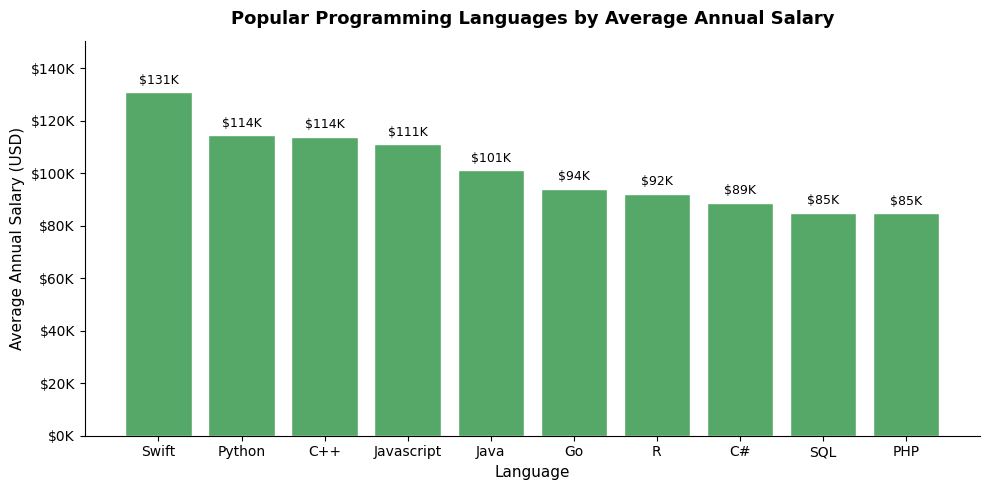

Chart saved: charts/popular_languages.png


In [2]:
# -- Bar chart: languages by salary, descending ------------------------------
df_sorted = df.sort_values('Salary', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_sorted['Language'], df_sorted['Salary'],
              color='#55A868', edgecolor='white')
ax.set_title('Popular Programming Languages by Average Annual Salary', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Language', fontsize=11)
ax.set_ylabel('Average Annual Salary (USD)', fontsize=11)
ax.bar_label(bars, labels=[f'${v/1e3:.0f}K' for v in df_sorted['Salary']],
             padding=4, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, df_sorted['Salary'].max() * 1.15)
plt.tight_layout()
plt.savefig('charts/popular_languages.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: charts/popular_languages.png')

### Findings
- **Swift** commands the highest average annual salary at **$130,801**, reflecting strong demand for iOS development.
- **Python ($114,383)** and **C++ ($113,865)** rank 2nd and 3rd — consistent with the survey data showing Python as the most desired language.
- **JavaScript ($110,981)** ranks 4th, reinforcing its continued market value despite Python overtaking it in desirability.
- **PHP ($84,727)** and **SQL ($84,793)** sit at the lower end — though SQL's ubiquity makes it essential regardless of salary ranking.